# Caso D · 01 EDA IAQ y ocupación en aulas

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **bronce** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Explorar el dataset In-Gauge mock de AULA01: variables ambientales, respuesta del CO₂ a la ocupación y patrón lectivo de la Comunidad Valenciana.


## 2. Qué se aprende

- Lectura del dataset In-Gauge / En-Gage.
- Cómo el CO₂ delata ocupación.
- Estacionalidad lectiva y horario de recreos.
- IAQ index y rangos OMS.


## 3. Contexto del caso de uso

El Caso D es el más alineado con AULA01 real. Lo que aprendamos aquí debe trasladarse directamente a sensores reales del IES.


## 4. Relación con CENTINELA+

Las 9 variables del gateway BMS coinciden con las del CSV (`Indoor_CO2` → `co2`, etc.).


## 5. Relación con Medallion

Bronce: CSV In-Gauge. Próximo notebook → plata.


## 6. Datos de entrada

`notebooks/_data/ingauge_aula01_mock.csv`.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Mapping In-Gauge → CAPTIA visto en docs.


## 9. Carga de datos o mock

Cargamos el CSV y derivamos día/horario lectivo.


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "ingauge_aula01_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["dow"] = df["timestamp"].dt.dayofweek
df.head()


,timestamp,Indoor_CO2,Indoor_Temp,Indoor_Hum,Indoor_Noise,Indoor_Lux,Occupied,People_Count,CoolingState,hour,dow
0,2024-09-09 00:00:00+02:00,420.4,16.78,39.18,36.4,77.8,0,0,0,0,0
1,2024-09-09 00:01:00+02:00,417.0,16.26,47.99,34.5,59.8,0,0,0,0,0
2,2024-09-09 00:02:00+02:00,425.1,16.49,42.79,31.2,0.0,0,0,0,0,0
3,2024-09-09 00:03:00+02:00,400.6,16.99,40.75,39.8,11.8,0,0,0,0,0
4,2024-09-09 00:04:00+02:00,442.2,16.82,36.47,35.4,0.0,0,0,0,0,0


## 10. Exploración paso a paso

Estadísticas básicas y picos por horario.


In [3]:
print(df[["Indoor_CO2", "Indoor_Temp", "Indoor_Hum", "Indoor_Lux", "People_Count"]].describe().round(2))
print("\nCO2 medio en horario lectivo (8-15h L-V):")
mask = (df["hour"].between(8, 14)) & (df["dow"] < 5)
print(df.loc[mask, "Indoor_CO2"].mean().round(1))


       Indoor_CO2  Indoor_Temp  Indoor_Hum  Indoor_Lux  People_Count
count    10080.00     10080.00    10080.00    10080.00      10080.00
mean       523.17        19.62       43.42      460.74          3.22
std        242.01         2.39        3.97      569.23          6.90
min        360.00        16.07       28.16        0.00          0.00
25%        400.80        17.62       40.75        0.00          0.00
50%        417.10        18.98       43.41       56.00          0.00
75%        443.30        20.75       46.10     1021.40          0.00
max       1325.00        24.99       63.36     1625.30         25.00

CO2 medio en horario lectivo (8-15h L-V):
951.2


## 11. Transformación bronce → plata

Notebook siguiente.


## 12. Construcción de capa oro

Notebook 03 (features).


## 13. Visualizaciones explicativas

Plot CO₂ vs ocupación durante 3 días lectivos.


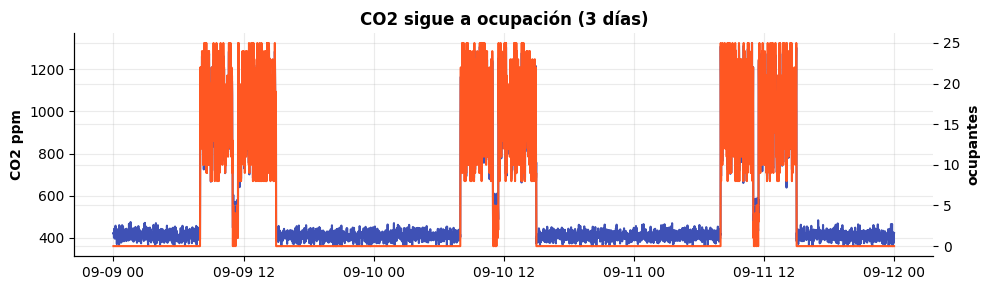

In [4]:
sample = df.head(60 * 24 * 3)  # 3 días
fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(sample["timestamp"], sample["Indoor_CO2"], color="#3F51B5", label="CO2")
ax1.set_ylabel("CO2 ppm")
ax2 = ax1.twinx()
ax2.plot(sample["timestamp"], sample["People_Count"], color="#FF5722", label="people")
ax2.set_ylabel("ocupantes")
plt.title("CO2 sigue a ocupación (3 días)")
plt.tight_layout()


## 14. Validaciones

1. CO2 nunca > 5000.
2. Temperatura entre 16 y 32.


In [5]:
assert df["Indoor_CO2"].between(300, 5000).all()
assert df["Indoor_Temp"].between(15, 32).all()
print("Rangos físicos OK")


Rangos físicos OK


## 15. Errores comunes

1. Confundir minutos con segundos.
2. Excluir horario nocturno (también informa: nivel base).
3. No identificar el recreo (11:00–11:30) como subcaso.


## 16. Ejercicios propuestos

1. Calcula `dCO2/dt` y compara su distribución con/sin clase.
2. Identifica los 3 picos de CO2 más altos del dataset.
3. Estima el caudal de ventilación equivalente.


## 17. Cómo se reutiliza con datos reales

Cuando AULA01 tenga histórico, este EDA aplica directamente. Las queries Flux equivalentes están en `docs/use-cases/case-d-iaq-occupancy.md`.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `04_case_D_iaq_occupancy/02_bronze_to_silver_iaq.ipynb`.
- Documento web del caso: `docs/use-cases/case-d-iaq-occupancy.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.
